In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
dane = pd.read_csv("College.csv")
dane.columns.values[0] = 'College_Names'
dane

,College_Names,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [0]:
dane = dane.dropna()
dane['Grad.Rate'] = dane['Grad.Rate'].clip(upper=100)
dane['PhD'] = dane['PhD'].clip(upper=100)
dane['Terminal'] = dane['Terminal'].clip(upper=100)
dane.shape

(777, 19)

In [0]:
dane.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.656371,79.702703,14.089704,22.743887,9660.171171,65.440154
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.321324,14.722359,3.958349,12.391801,5221.768440,17.118804
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.000000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.000000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.000000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.000000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,100.000000,100.000000,39.800000,64.000000,56233.000000,100.000000


In [0]:
#podzial zmiennych na kat i num
var_num = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend']
var_cat = ['Private']

In [0]:
korelacja = dane[var_num + ['Grad.Rate']].corr()['Grad.Rate'].drop('Grad.Rate')
korelacja.sort_values(ascending=False)

Outstate       0.573612
Top10perc      0.498118
perc.alumni    0.492887
Top25perc      0.480346
Room.Board     0.425808
Expend         0.392195
PhD            0.310732
Terminal       0.293533
Apps           0.146964
Accept         0.066762
Books          0.000649
Enroll        -0.022049
F.Undergrad   -0.078293
P.Undergrad   -0.257135
Personal      -0.268588
S.F.Ratio     -0.307838
Name: Grad.Rate, dtype: float64

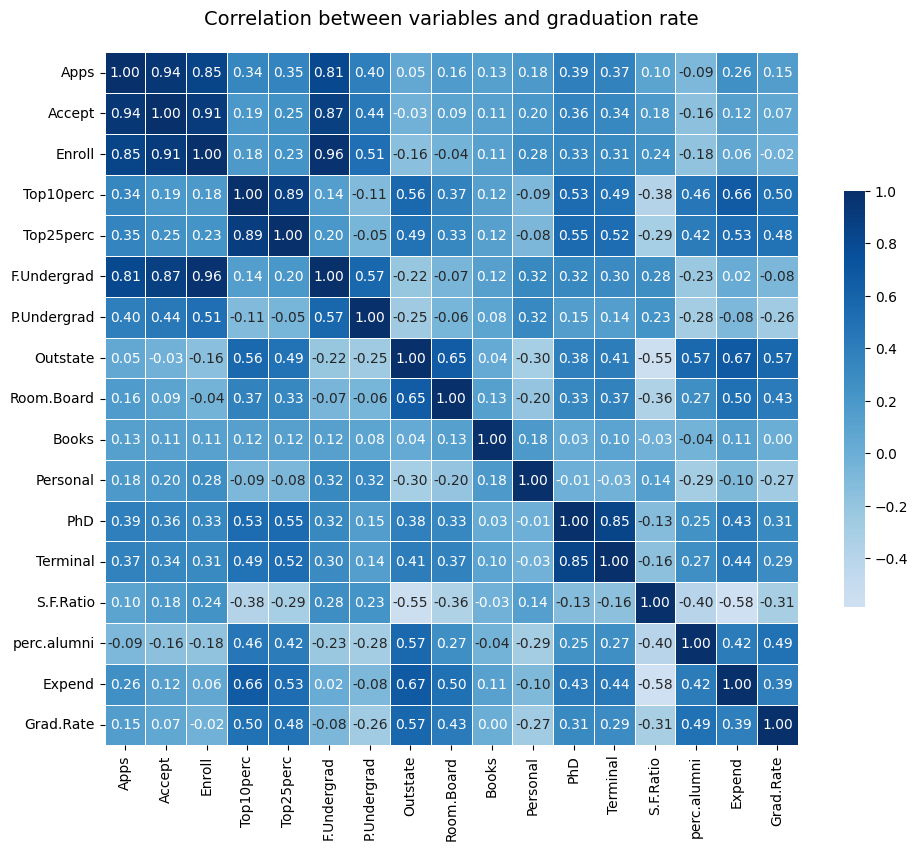

In [0]:
plt.figure(figsize=(12, 9))
korelacja_heatmap = dane[var_num + ['Grad.Rate']].corr()

sns.heatmap(korelacja_heatmap, annot=True, fmt='.2f', cmap='Blues', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title('Correlation between variables and graduation rate', fontsize='14',pad='20' )
plt.savefig('korelacja.png')
plt.show()

###Outstate najwyższa wartość korelacji w stosunku do odsetku kończących studia

#Podział danych na zbiór uczący i testowy

In [0]:
from sklearn.model_selection import train_test_split

In [0]:
y = dane['Grad.Rate']
X = dane.drop(['College_Names', 'Grad.Rate'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=327734)

In [0]:
X_train.shape

(621, 17)

In [0]:
X_test.shape

(156, 17)

In [0]:
#kopia zap danych num
stand_X_train = X_train.copy()
stand_X_test = X_test.copy()

In [0]:
#skalowanie danych num
from sklearn.preprocessing import StandardScaler

skaler = StandardScaler()
stand_X_train[var_num] = skaler.fit_transform(stand_X_train[var_num]) 
stand_X_test[var_num] = skaler.transform(stand_X_test[var_num])

In [0]:
#skalowanie danych kat

from sklearn.preprocessing import OneHotEncoder

enkoder = OneHotEncoder(sparse_output = False, drop = 'first').set_output(transform='pandas')

temp = enkoder.fit_transform(stand_X_train[var_cat])
X_train = stand_X_train.drop(columns = var_cat)
X_train = pd.concat([X_train,temp],axis=1)

temp = enkoder.transform(stand_X_test[var_cat])
X_test = stand_X_test.drop(columns = var_cat)
X_test = pd.concat([X_test,temp],axis=1)

#Model Regresji Liniowej

In [0]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [0]:
model_reg_lin = LinearRegression()
model_reg_lin.fit(X_train, y_train)

LinearRegression()

In [0]:
y_pred_reg_lin=model_reg_lin.predict(X_test)

In [0]:
pd.DataFrame(model_reg_lin.coef_, index = model_reg_lin.feature_names_in_, columns = ['współczynnik modelu'])

,współczynnik modelu
Apps,5.860915
Accept,-2.269894
Enroll,0.958342
Top10perc,1.979670
Top25perc,2.475248
F.Undergrad,-1.484107
P.Undergrad,-2.461773
Outstate,4.274514
Room.Board,1.957225
Books,-0.276390


####Rownanie modelu 

In [0]:
print('karp = ', end='')
for b,n in zip(model_reg_lin.coef_, model_reg_lin.feature_names_in_):
    print(round(b,2), '*', n, '+ ',end='') 
print(round(model_reg_lin.intercept_,2))

karp = 5.86 * Apps + -2.27 * Accept + 0.96 * Enroll + 1.98 * Top10perc + 2.48 * Top25perc + -1.48 * F.Undergrad + -2.46 * P.Undergrad + 4.27 * Outstate + 1.96 * Room.Board + -0.28 * Books + -0.74 * Personal + 1.54 * PhD + -1.49 * Terminal + 0.17 * S.F.Ratio + 3.16 * perc.alumni + -3.07 * Expend + 4.05 * Private_Yes + 62.84


In [0]:
ocena_R2 = model_reg_lin.score(X_test, y_test)
mae_reg_lin = mean_absolute_error(y_test, y_pred_reg_lin)
mse_reg_lin = mean_squared_error(y_test, y_pred_reg_lin)
rmse_reg_lin = np.sqrt(mse_reg_lin)

###Ocena modelu Regresji Liniowej

In [0]:
print(f'Dopasowanie modelu regresji liniowej R² wynosi: {round(ocena_R2 * 100, 2)}')
print(f'Średni błąd absolutny MAE wynosi: {round(mae_reg_lin, 2)}')
print(f'Pierwiastek z błędu średniokwadratowego RMSE wynosi: {round(rmse_reg_lin, 2)}')


Dopasowanie modelu regresji liniowej R² wynosi: 44.28
Średni błąd absolutny MAE wynosi: 9.29
Pierwiastek z błędu średniokwadratowego RMSE wynosi: 12.01


#Model Random Forest

In [0]:
from sklearn.ensemble import RandomForestRegressor

In [0]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=327734)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

ocena_R2_rf = model_rf.score(X_test, y_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f'Dopasowanie modelu Random Forest R² wynosi: {round(ocena_R2_rf*100, 2)}%')
print(f'Średni błąd absolutny MAE wynosi: {round(mae_rf, 2)}')
print(f'Pierwiastek z błędu średniokwadratowego RMSE wynosi: {round(rmse_rf, 2)}')

Dopasowanie modelu Random Forest R² wynosi: 38.04%
Średni błąd absolutny MAE wynosi: 9.53
Pierwiastek z błędu średniokwadratowego RMSE wynosi: 12.67


In [0]:
model_rf200 = RandomForestRegressor(n_estimators=200, random_state=327734)
model_rf200.fit(X_train, y_train)

y_pred_rf200 = model_rf200.predict(X_test)

ocena_R2_rf200 = model_rf200.score(X_test, y_test)
mae_rf200 = mean_absolute_error(y_test, y_pred_rf)
mse_rf200 = mean_squared_error(y_test, y_pred_rf)
rmse_rf200 = np.sqrt(mse_rf)

print(f'Dopasowanie modelu Random Forest R² wynosi: {round(ocena_R2_rf200*100, 2)}%')
print(f'Średni błąd absolutny MAE wynosi: {round(mae_rf200, 2)}')
print(f'Pierwiastek z błędu średniokwadratowego RMSE wynosi: {round(rmse_rf200, 2)}')

Dopasowanie modelu Random Forest R² wynosi: 39.49%
Średni błąd absolutny MAE wynosi: 9.53
Pierwiastek z błędu średniokwadratowego RMSE wynosi: 12.67


###Tune Modelu za pomocą GridSearchCV

In [0]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestRegressor(random_state=327734)


grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

print(f'Testowanie {len(param_grid["n_estimators"]) * len(param_grid["max_depth"]) * len(param_grid["min_samples_split"]) * len(param_grid["max_features"])} kombinacji parametrów')

grid_search.fit(X_train, y_train)

print('Najlepsze Parametry:\n')
for param, value in grid_search.best_params_.items():
    print(f'{param}: {value}')

Testowanie 72 kombinacji parametrów
Najlepsze Parametry:

max_depth: 20
max_features: sqrt
min_samples_split: 2
n_estimators: 300


In [0]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

ocena_R2_best = best_model.score(X_test, y_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

In [0]:
print(f'Dopasowanie modelu Random Forest dla najlepszych parametrów: {round(ocena_R2_best*100, 2)}%')
print(f'Poprawa o {round((ocena_R2_best - ocena_R2_rf)*100, 2)}pkt %\n')
print(f'Średni błąd absolutny MAE dla ulepszonego modelu Random Forest wynosi:  {round(mae_best, 2)}\n')
print(f'Pierwiastek z błędu średniokwadratowego RMSE dla ulepszonego modelu Random Forest wynosi: {round(rmse_best, 2)}')

Dopasowanie modelu Random Forest dla najlepszych parametrów: 41.74%
Poprawa o 3.7pkt %

Średni błąd absolutny MAE dla ulepszonego modelu Random Forest wynosi:  9.24

Pierwiastek z błędu średniokwadratowego RMSE dla ulepszonego modelu Random Forest wynosi: 12.29


###Eksport zbioru testowego i uczącego oraz wyników predykcji modelu regresji liniowej

In [0]:
train_set = X_train.copy()
train_set['Grad.Rate'] = y_train
train_set=pd.DataFrame(train_set)

test_set = X_test.copy()
test_set['Grad.Rate'] = y_test
test_set=pd.DataFrame(test_set)

train_set.to_csv('train_set.csv')
test_set.to_csv('test_set.csv')

In [0]:
y_pred_csv = pd.DataFrame(y_pred_reg_lin)
y_pred_csv.to_csv('Wyniki_predykcji_reg_lin.csv')